In [1]:
!pip install -q scanpy
!pip install -q scvi-tools

In [2]:
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import scvi
import umap
import warnings

In [3]:
#Helpers
def to_dense(X):
    if sp.issparse(X):
        return X.toarray().astype(np.float32)
    return np.asarray(X, dtype=np.float32)

def max_f1_score(scores_h, scores_d):
    """Max-F1 over the full PR curve (healthy=0, DCM=1)."""
    y = np.concatenate([np.zeros(len(scores_h)), np.ones(len(scores_d))])
    s = np.concatenate([scores_h, scores_d])
    p, r, t = precision_recall_curve(y, s)
    f1 = 2 * p * r / (p + r + 1e-10)
    i  = np.argmax(f1)
    return float(f1[i]), float(t[i] if i < len(t) else t[-1])

def compute_auprc(scores_h, scores_d):
    """Global AUPRC (healthy=0, DCM=1)."""
    y = np.concatenate([np.zeros(len(scores_h)), np.ones(len(scores_d))])
    s = np.concatenate([scores_h, scores_d])
    return float(average_precision_score(y, s))

def per_celltype_auprc(scores_h, scores_d, adata_h, adata_d,
                        celltype_col="cell_type"):
    """
    Per-cell-type AUPRC.
    For each cell type C:
      negatives = healthy cells of type C
      positives = DCM cells of type C
    Returns a dict: {cell_type: {"n_h", "n_d", "auprc", "baseline", "fold"}}
    """
    results = {}
    cts_h = set(adata_h.obs[celltype_col].unique())
    cts_d = set(adata_d.obs[celltype_col].unique())
    shared_cts = cts_h & cts_d

    for ct in shared_cts:
        mask_h = (adata_h.obs[celltype_col] == ct).values
        mask_d = (adata_d.obs[celltype_col] == ct).values
        n_h, n_d = mask_h.sum(), mask_d.sum()
        if n_h < 5 or n_d < 5:
            continue
        s_h = scores_h[mask_h]
        s_d = scores_d[mask_d]
        ap       = compute_auprc(s_h, s_d)
        baseline = n_d / (n_h + n_d)
        results[ct] = {
            "n_h":      int(n_h),
            "n_d":      int(n_d),
            "auprc":    ap,
            "baseline": baseline,
            "fold":     ap / (baseline + 1e-10),
        }
    return results

def per_celltype_max_f1(scores_h, scores_d, adata_h, adata_d,
                         celltype_col="cell_type"):
    """Per-cell-type Max-F1."""
    results = {}
    cts_h = set(adata_h.obs[celltype_col].unique())
    cts_d = set(adata_d.obs[celltype_col].unique())
    shared_cts = cts_h & cts_d

    for ct in shared_cts:
        mask_h = (adata_h.obs[celltype_col] == ct).values
        mask_d = (adata_d.obs[celltype_col] == ct).values
        n_h, n_d = mask_h.sum(), mask_d.sum()
        if n_h < 5 or n_d < 5:
            continue
        s_h = scores_h[mask_h]
        s_d = scores_d[mask_d]
        f1, thr = max_f1_score(s_h, s_d)
        results[ct] = {"n_h": int(n_h), "n_d": int(n_d),
                       "max_f1": f1, "threshold": thr}
    return results

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
path = "/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/"

train_h = sc.read_h5ad(path + "train_set_1.h5ad")
val_h   = sc.read_h5ad(path + "validation_set_1.h5ad")
test_h  = sc.read_h5ad(path + "healthy_test_set_1.h5ad")
test_d  = sc.read_h5ad(path + "DCM_test_set_1.h5ad")

CELLTYPE_COL = "celltype"

In [6]:
hvgs = train_h.var_names

#standarize input dims
def align_genes(adata, hvgs):
    shared  = hvgs.intersection(adata.var_names)
    missing = hvgs.difference(adata.var_names)
    ad = adata[:, shared].copy()
    if len(missing) > 0:
        print(f"  Warning: {len(missing)} genes missing - zero-padding")
        zeros = sc.AnnData(
            X=sp.csr_matrix((ad.n_obs, len(missing))),
            obs=ad.obs.copy(),
            var=pd.DataFrame(index=missing)
        )
        ad = sc.concat([ad, zeros], axis=1)
        ad = ad[:, hvgs].copy()
    return ad

train_h = align_genes(train_h, hvgs)
val_h   = align_genes(val_h,   hvgs)
test_h  = align_genes(test_h,  hvgs)
test_d  = align_genes(test_d,  hvgs)

In [7]:
X_train  = to_dense(train_h.X)
X_val    = to_dense(val_h.X)
X_test_h = to_dense(test_h.X)
X_test_d = to_dense(test_d.X)

In [8]:
N_PCS = 50
pca = PCA(n_components=N_PCS, random_state=42)
Z_train  = pca.fit_transform(X_train)
Z_val    = pca.transform(X_val)
Z_test_h = pca.transform(X_test_h)
Z_test_d = pca.transform(X_test_d)
print(f"PCA explained variance ({N_PCS} PCs): "
      f"{pca.explained_variance_ratio_.sum():.3f}")

PCA explained variance (50 PCs): 0.529


## Model 1: scVI

Deep learning model designed for single-cell data.

Trained only on healthy cells
Once trained, it calculates the marginal log-likelihood for the test cells.

In [9]:
scvi.model.SCVI.setup_anndata(train_h)

vae = scvi.model.SCVI(
    train_h,
    n_latent=10,
    n_layers=2,
    gene_likelihood="normal",
    dropout_rate=0.1,
)
vae.train(
    max_epochs=300,
    early_stopping=True,
    early_stopping_patience=20,
    validation_size=0.1,
    plan_kwargs={"lr": 1e-3},
)

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VI

Training:   0%|          | 0/300 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 20 records. Best score: -1160.771. Signaling Trainer to stop.


In [10]:
scores_scvi_h = -np.asarray(
    vae.get_marginal_ll(test_h, n_mc_samples=100,
                        return_mean=False, batch_size=512), dtype=np.float32)
scores_scvi_d = -np.asarray(
    vae.get_marginal_ll(test_d, n_mc_samples=100,
                        return_mean=False, batch_size=512), dtype=np.float32)


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


## Model 2: PCA + KNN

Geometric method for anomaly detection. It maps the test cells into the 50-dimensional PCA space created by the training data.

For every test cell, it calculates the average distance to its 5 nearest healthy neighbors.

In [11]:
knn = NearestNeighbors(n_neighbors=5, metric="euclidean", n_jobs=-1)
knn.fit(Z_train)

scores_knn_h = knn.kneighbors(Z_test_h)[0].mean(axis=1)
scores_knn_d = knn.kneighbors(Z_test_d)[0].mean(axis=1)

## Model 3: Isolation Forest

The Isolation Forest works on the principle that "anomalies are few and different." It randomly splits the data into branches.

- The Logic: Because healthy cells are similar and plentiful, it takes many "splits" to isolate one.

- The Anomaly: Because DCM cells are different from the norm, they can be isolated in very few splits. The shorter the "path" to isolate a cell, the more likely it is to be an anomaly.

In [12]:
iso = IsolationForest(n_estimators=200, contamination="auto",
                      random_state=42, n_jobs=-1)
iso.fit(Z_train)

scores_if_h = -iso.decision_function(Z_test_h)
scores_if_d = -iso.decision_function(Z_test_d)

## Results

#### Global Max-F1 and AUPRC Table

In [13]:
baseline_ap = len(test_d) / (len(test_h) + len(test_d))

f1_scvi, _ = max_f1_score(scores_scvi_h, scores_scvi_d)
f1_knn,  _ = max_f1_score(scores_knn_h,  scores_knn_d)
f1_if,   _ = max_f1_score(scores_if_h,   scores_if_d)

ap_scvi = compute_auprc(scores_scvi_h, scores_scvi_d)
ap_knn  = compute_auprc(scores_knn_h,  scores_knn_d)
ap_if   = compute_auprc(scores_if_h,   scores_if_d)

print("\n" + "="*52)
print(f"{'Model':<22} {'Max-F1':>8}  {'AUPRC':>8}")
print("-"*52)
print(f"{'scVI':<22} {f1_scvi:>8.4f}  {ap_scvi:>8.4f}")
print(f"{'PCA + KNN':<22} {f1_knn:>8.4f}  {ap_knn:>8.4f}")
print(f"{'Isolation Forest':<22} {f1_if:>8.4f}  {ap_if:>8.4f}")
print(f"{'Random baseline':<22} {'—':>8}  {baseline_ap:>8.4f}")
print("="*52)


Model                    Max-F1     AUPRC
----------------------------------------------------
scVI                     0.9842    0.9786
PCA + KNN                0.9831    0.9884
Isolation Forest         0.9835    0.9851
Random baseline               —    0.9668


#### Per cell Max-F1 and AUPRC Table

In [14]:
#Per-cell-type AUPRC
ct_auprc_scvi = per_celltype_auprc(scores_scvi_h, scores_scvi_d,
                                    test_h, test_d, CELLTYPE_COL)
ct_auprc_knn  = per_celltype_auprc(scores_knn_h,  scores_knn_d,
                                    test_h, test_d, CELLTYPE_COL)
ct_auprc_if   = per_celltype_auprc(scores_if_h,   scores_if_d,
                                    test_h, test_d, CELLTYPE_COL)

#Per-cell-type Max-F1
ct_f1_scvi = per_celltype_max_f1(scores_scvi_h, scores_scvi_d,
                                  test_h, test_d, CELLTYPE_COL)
ct_f1_knn  = per_celltype_max_f1(scores_knn_h,  scores_knn_d,
                                  test_h, test_d, CELLTYPE_COL)
ct_f1_if   = per_celltype_max_f1(scores_if_h,   scores_if_d,
                                  test_h, test_d, CELLTYPE_COL)


CELL_ORDER = sorted(
    ct_auprc_scvi.keys(),
    key=lambda c: ct_auprc_scvi[c]["n_d"]
)

# AUPRC table
print("\n" + "="*80)
print(f"  Per-Cell-Type AUPRC")
print(f"{'-'*80}")
print(f"  {'Cell Type':<20} {'N_h':>5} {'N_d':>7}  "
      f"{'KNN':>7}  {'IF':>7}  {'scVI':>7}  {'Baseline':>9}")
print(f"{'-'*80}")
for ct in CELL_ORDER:
    r = ct_auprc_scvi.get(ct, {})
    print(f"  {ct:<20} "
          f"{r.get('n_h',0):>5} {r.get('n_d',0):>7}  "
          f"{ct_auprc_knn.get(ct,  {}).get('auprc', 0):>7.4f}  "
          f"{ct_auprc_if.get(ct,   {}).get('auprc', 0):>7.4f}  "
          f"{r.get('auprc', 0):>7.4f}  "
          f"{r.get('baseline', 0):>9.4f}")
print(f"{'-'*80}")
print(f"  {'GLOBAL':<20} {len(test_h):>5} {len(test_d):>7}  "
      f"{ap_knn:>7.4f}  {ap_if:>7.4f}  {ap_scvi:>7.4f}  "
      f"{baseline_ap:>9.4f}")
print("="*80)

# Max-F1 table
print("\n" + "="*70)
print(f"  Per-Cell-Type Max-F1")
print(f"{'-'*70}")
print(f"  {'Cell Type':<20} {'N_h':>5} {'N_d':>7}  "
      f"{'KNN':>7}  {'IF':>7}  {'scVI':>7}")
print(f"{'-'*70}")
for ct in CELL_ORDER:
    r = ct_f1_scvi.get(ct, {})
    print(f"  {ct:<20} "
          f"{r.get('n_h',0):>5} {r.get('n_d',0):>7}  "
          f"{ct_f1_knn.get(ct, {}).get('max_f1', 0):>7.4f}  "
          f"{ct_f1_if.get(ct,  {}).get('max_f1', 0):>7.4f}  "
          f"{r.get('max_f1', 0):>7.4f}")
print(f"{'-'*70}")
print(f"  {'GLOBAL':<20} {len(test_h):>5} {len(test_d):>7}  "
      f"{f1_knn:>7.4f}  {f1_if:>7.4f}  {f1_scvi:>7.4f}")
print("="*70)


  Per-Cell-Type AUPRC
--------------------------------------------------------------------------------
  Cell Type              N_h     N_d      KNN       IF     scVI   Baseline
--------------------------------------------------------------------------------
  NK_Cells                 9     328   0.9559   0.9568   0.9840     0.9733
  Monocytes               17     513   0.9890   0.9809   0.9953     0.9679
  Smooth_Muscle           29     601   0.9671   0.9371   0.9624     0.9540
  T_Cells                 27    2073   0.9852   0.9906   0.9870     0.9871
  Macrophages             65    3391   0.9953   0.9939   0.9926     0.9812
  Pericytes              105    4634   0.9881   0.9801   0.9824     0.9778
  Endothelium            317    8405   0.9885   0.9714   0.9651     0.9637
  Fibroblasts            688   16676   0.9960   0.9941   0.9882     0.9604
--------------------------------------------------------------------------------
  GLOBAL                1257   36621   0.9884   0.9851   0.

#### Percision-Recall Curves

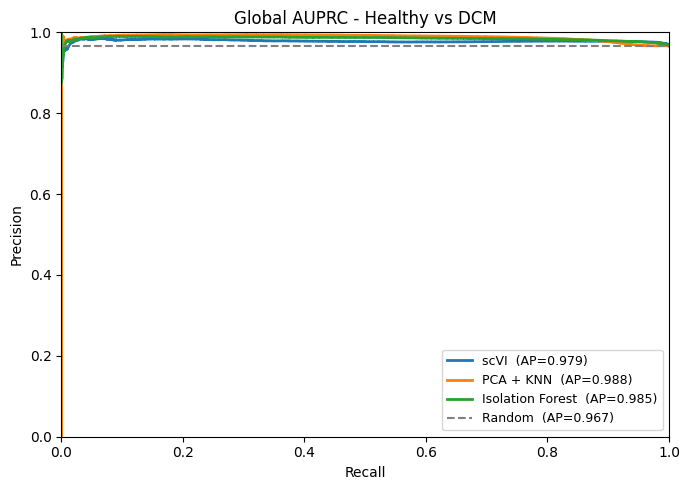

In [15]:
labels_global = np.concatenate([
    np.zeros(len(test_h)), np.ones(len(test_d))
])

fig, ax = plt.subplots(figsize=(7, 5))
for scores, name, ap in [
    (np.concatenate([scores_scvi_h, scores_scvi_d]), "scVI",             ap_scvi),
    (np.concatenate([scores_knn_h,  scores_knn_d]),  "PCA + KNN",        ap_knn),
    (np.concatenate([scores_if_h,   scores_if_d]),   "Isolation Forest", ap_if),
]:
    p, r, _ = precision_recall_curve(labels_global, scores)
    ax.plot(r, p, lw=2, label=f"{name}  (AP={ap:.3f})")

ax.axhline(baseline_ap, ls="--", color="gray",
           label=f"Random  (AP={baseline_ap:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Global AUPRC - Healthy vs DCM")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

#### AUPRC Lift Table

In [16]:
print(f"\n{'='*75}")
print(f"  AUPRC Lift over Random Baseline (AUPRC - baseline)")
print(f"{'-'*75}")
print(f"  {'Cell Type':<20} {'Baseline':>9}  {'KNN lift':>9}  {'IF lift':>9}  {'scVI lift':>10}")
print(f"{'-'*75}")

for ct in CELL_ORDER:
    base = ct_auprc_scvi.get(ct, {}).get("baseline", 0)
    knn  = ct_auprc_knn.get(ct,  {}).get("auprc", 0)
    iff  = ct_auprc_if.get(ct,   {}).get("auprc", 0)
    sv   = ct_auprc_scvi.get(ct, {}).get("auprc", 0)
    print(f"  {ct:<20} {base:>9.4f}  "
          f"{knn-base:>+9.4f}  {iff-base:>+9.4f}  {sv-base:>+10.4f}")

print(f"{'-'*75}")
print(f"  {'GLOBAL':<20} {baseline_ap:>9.4f}  "
      f"{ap_knn-baseline_ap:>+9.4f}  "
      f"{ap_if-baseline_ap:>+9.4f}  "
      f"{ap_scvi-baseline_ap:>+9.4f}")
print(f"{'='*75}")


  AUPRC Lift over Random Baseline (AUPRC - baseline)
---------------------------------------------------------------------------
  Cell Type             Baseline   KNN lift    IF lift   scVI lift
---------------------------------------------------------------------------
  NK_Cells                0.9733    -0.0174    -0.0165     +0.0107
  Monocytes               0.9679    +0.0211    +0.0129     +0.0274
  Smooth_Muscle           0.9540    +0.0131    -0.0168     +0.0084
  T_Cells                 0.9871    -0.0020    +0.0034     -0.0001
  Macrophages             0.9812    +0.0141    +0.0127     +0.0114
  Pericytes               0.9778    +0.0102    +0.0022     +0.0046
  Endothelium             0.9637    +0.0249    +0.0077     +0.0015
  Fibroblasts             0.9604    +0.0356    +0.0337     +0.0278
---------------------------------------------------------------------------
  GLOBAL                  0.9668    +0.0216    +0.0183    +0.0118


#### Per-cell AUPRC and AUPRC Lift per cell visualization

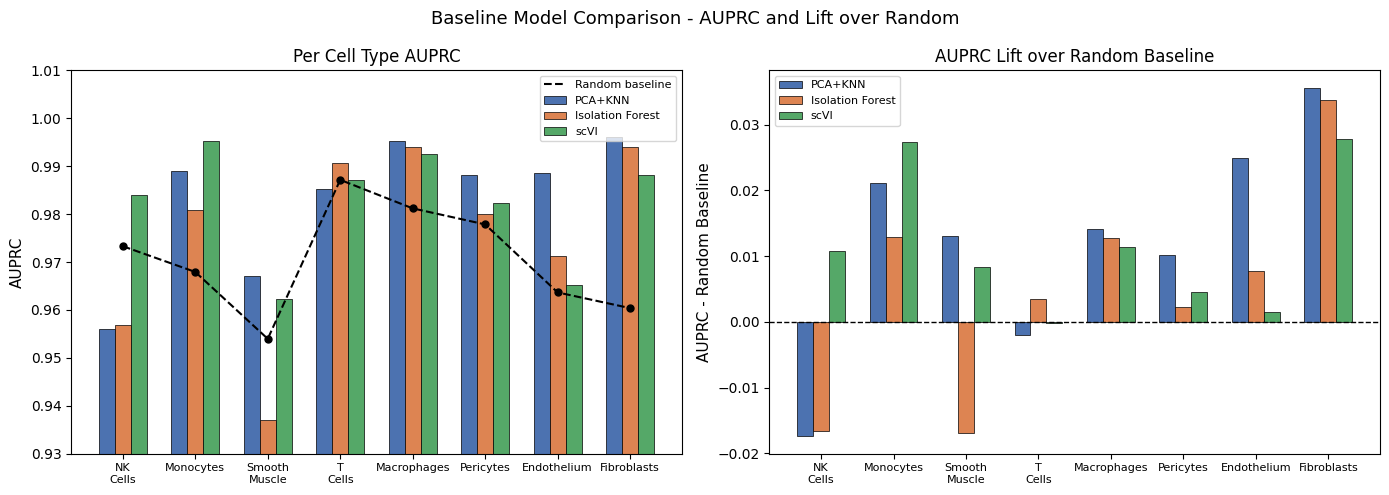

  NK_Cells             best=scVI   lift=+0.0107  (n_healthy=9)
  Monocytes            best=scVI   lift=+0.0274  (n_healthy=17)
  Smooth_Muscle        best=KNN    lift=+0.0131  (n_healthy=29)
  T_Cells              best=IF     lift=+0.0034  (n_healthy=27)
  Macrophages          best=KNN    lift=+0.0141  (n_healthy=65)
  Pericytes            best=KNN    lift=+0.0102  (n_healthy=105)
  Endothelium          best=KNN    lift=+0.0249  (n_healthy=317)
  Fibroblasts          best=KNN    lift=+0.0356  (n_healthy=688)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(CELL_ORDER))
w = 0.22
colors_bar = ["#4C72B0", "#DD8452", "#55A868"]

model_data = [
    ("PCA+KNN",        ct_auprc_knn,  colors_bar[0]),
    ("Isolation Forest", ct_auprc_if, colors_bar[1]),
    ("scVI",           ct_auprc_scvi, colors_bar[2]),
]

for i, (mname, mres, col) in enumerate(model_data):
    vals = [mres.get(ct, {}).get("auprc", 0) for ct in CELL_ORDER]
    ax.bar(x + (i-1)*w, vals, width=w, label=mname,
           color=col, edgecolor="black", linewidth=0.5)

baselines = [ct_auprc_scvi.get(ct, {}).get("baseline", 0) for ct in CELL_ORDER]
ax.plot(x, baselines, "k--", lw=1.5, label="Random baseline", zorder=5)
ax.scatter(x, baselines, color="black", s=25, zorder=6)

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in CELL_ORDER],
                    fontsize=8, ha="center")
ax.set_ylabel("AUPRC", fontsize=11)
ax.set_title("Per Cell Type AUPRC", fontsize=12)
ax.legend(fontsize=8)
ax.set_ylim([0.93, 1.01])

# auprc lift
ax2 = axes[1]
for i, (mname, mres, col) in enumerate(model_data):
    lifts = [mres.get(ct, {}).get("auprc", 0)
             - ct_auprc_scvi.get(ct, {}).get("baseline", 0)
             for ct in CELL_ORDER]
    ax2.bar(x + (i-1)*w, lifts, width=w, label=mname,
            color=col, edgecolor="black", linewidth=0.5)

ax2.axhline(0, color="black", lw=1.0, ls="--")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CELL_ORDER],
                     fontsize=8, ha="center")
ax2.set_ylabel("AUPRC - Random Baseline", fontsize=11)
ax2.set_title("AUPRC Lift over Random Baseline", fontsize=12)
ax2.legend(fontsize=8)

for j, ct in enumerate(CELL_ORDER):
    n_d = ct_auprc_scvi.get(ct, {}).get("n_d", 0)
    n_h = ct_auprc_scvi.get(ct, {}).get("n_h", 0)


plt.suptitle("Baseline Model Comparison - AUPRC and Lift over Random",
             fontsize=13)
plt.tight_layout()
plt.show()

for ct in CELL_ORDER:
    base = ct_auprc_scvi.get(ct, {}).get("baseline", 0)
    best_model = max(
        [("KNN",  ct_auprc_knn.get(ct,  {}).get("auprc", 0)),
         ("IF",   ct_auprc_if.get(ct,   {}).get("auprc", 0)),
         ("scVI", ct_auprc_scvi.get(ct, {}).get("auprc", 0))],
        key=lambda x: x[1]
    )
    lift = best_model[1] - base
    n_h  = ct_auprc_scvi.get(ct, {}).get("n_h", 0)
    print(f"  {ct:<20} best={best_model[0]:<6} "
          f"lift={lift:+.4f}  (n_healthy={n_h})")